# Sea Level Trend

## Import Libraries

In [1]:
import xarray as xr
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import os
from urllib.request import urlretrieve
import requests, re
import pandas as pd
from scipy.stats import linregress

## User Input

In [ ]:
# Pick one station by uncommenting and updating the 3 values below.
# Available stations from config/stations.py:
# station_id = "IDO70051"; country = "Cook Islands"; location = "Avatiu"
# station_id = "IDO70054"; country = "Fiji"; location = "Lautoka"
# station_id = "IDO70063"; country = "Fiji"; location = "Suva"
# station_id = "IDO70057"; country = "Federated States of Micronesia"; location = "Dekehtik"
# station_id = "IDO70060"; country = "Kiribati"; location = "Tarawa (Betio)"
# station_id = "IDO70055"; country = "Nauru"; location = "Nauru"
# station_id = "IDO70061"; country = "Solomon Islands"; location = "Honiara"
# station_id = "IDO70053"; country = "Tonga"; location = "Nuku'alofa"
# station_id = "IDO70056"; country = "Tuvalu"; location = "Funafuti"
# station_id = "IDO70059"; country = "Vanuatu"; location = "Port Vila"
# station_id = "IDO70062"; country = "Samoa"; location = "Apia"
# station_id = "IDO70058"; country = "Papua New Guinea"; location = "Lombrum"
station_id = "IDO70052"; country = "Marshall Islands"; location = "Uliga"

#station_id = "IDO70063"
#country = "Fiji"
#location = "Suva"
url = f"https://reg.bom.gov.au/ntc/{station_id}/{station_id}SLD.txt"
temp_file = f"{station_id}SLD.txt"

: 

## Download Data From Tide Gauge

In [ ]:
response = requests.get(url)
response.raise_for_status()
with open(temp_file, 'w', encoding='utf-8') as f:
    f.write(response.text)

# Process data
with open(temp_file, 'r') as file:
    content = file.read()

# Extract the data rows (lines that start with numbers)
data_lines = []
for line in content.split('\n'):
    # Look for lines that start with numbers (the data rows)
    if re.match(r'^\s*\d+', line):
        data_lines.append(line.strip())

# Process each data line, stopping when we encounter "Totals"
data = []
for line in data_lines:
    # Split on multiple spaces and filter out empty strings
    values = [x for x in line.split(' ') if x != '']
    
    # Stop processing when we reach "Totals" or any non-data row
    if not values or values[0] == 'Totals' or not values[0].isdigit():
        break
    
    # Convert numeric values to appropriate types
    row = []
    for i, value in enumerate(values):
        if i < 2:  # Month and Year are integers
            row.append(int(value))
        else:  # Other values are floats
            try:
                row.append(float(value))
            except ValueError:
                row.append(value)
    
    data.append(row)

: 

## Trend Analysis

In [ ]:
# Create DataFrame
columns = ['Mth', 'Year', 'Gaps', 'Good', 'Minimum', 'Maximum', 'Mean', 'St Devn']
df = pd.DataFrame(data, columns=columns)

#df = Plotter.read_sea_level_data(temp_file)
df = df.dropna(subset=["Mean"])
# === Step 2: Create datetime index ===
df["Date"] = pd.to_datetime(df["Year"].astype(int).astype(str) + "-" +
                            df["Mth"].astype(int).astype(str) + "-15")

# Calculate trend

time_num = df["Date"].map(datetime.toordinal).values  # convert dates to numeric
means = df["Mean"].values
mean_of_means = np.mean(means)
print(f"Mean of means: {mean_of_means:.4f}")
# === Step 4: Linear regression trend ===
slope, intercept, r_value, p_value, std_err = linregress(time_num, means)
trend = intercept + slope * time_num
# Convert slope to mm/year (assuming Mean is in meters)
slope_mm_year = slope * 365.25 * 1000  
#x = np.arange(len(df))
#slope_mean, intercept_mean, _, _, _ = linregress(x, df["Mean"])
#slope_mm_per_year = slope_mean * 12 * 1000
#df["Mean_Trend"] = intercept_mean + slope_mean * x

Mean of means: 1.2026


: 

## Plot

Text(1.05, -0.08, 'Vertical Land Motion (VLM) has not been removed.')

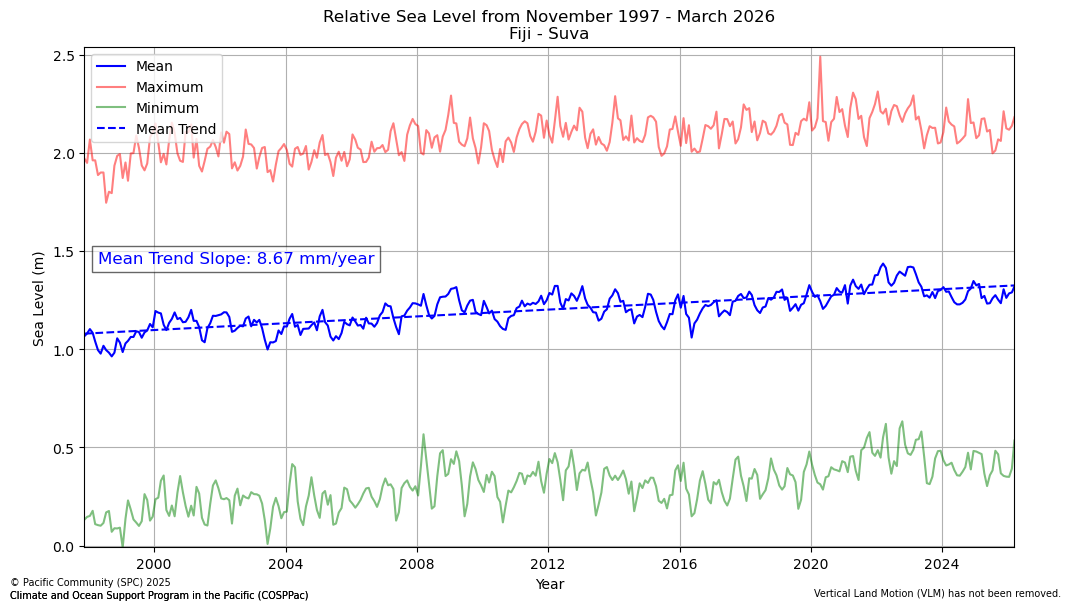

: 

In [ ]:

# Create plot
fig, ax = plt.subplots(figsize=(12, 6.5))
ax.plot(df["Date"], df["Mean"], label="Mean", color="blue")
ax.plot(df["Date"], df["Maximum"], label="Maximum", color="red", alpha=0.5)
ax.plot(df["Date"], df["Minimum"], label="Minimum", color="green", alpha=0.5)
ax.plot(df["Date"], trend, "--", color="blue", label="Mean Trend")

# Add annotations
latest_date = df["Date"].max()
month_name = latest_date.strftime("%B")
yearname = latest_date.strftime("%Y")
latest_date2 = df["Date"].min()
month_name2 = latest_date2.strftime("%B")
yearname2 = latest_date2.strftime("%Y")

ax.text(
    df["Date"].iloc[5], max(df["Mean"]),
    f"Mean Trend Slope: {slope_mm_year:.2f} mm/year",
    fontsize=12, color="blue", bbox=dict(facecolor="white", alpha=0.6)
)


# Set axis limits
ax.set_xlim([df["Date"].min(), df["Date"].max()])
ax.set_ylim([
    min(df["Minimum"].min(), trend.min()) * 0.98,
    max(df["Maximum"].max(), trend.max()) * 1.02
])

# Formatting
ax.set_xlabel("Year")
ax.set_ylabel("Sea Level (m)")
ax.legend()
ax.set_title(f"Relative Sea Level from {month_name2} {yearname2} - {month_name} {yearname}\n{country} - {location}")
ax.grid(True)

# Add footer text
ax2_pos = ax.get_position()
ax.text(
    -0.08, ax2_pos.y0-0.17, "© Pacific Community (SPC) 2025",
    transform=ax.transAxes, fontsize=7, verticalalignment='top'
)
ax.text(
    -0.08, ax2_pos.y0-0.195, "Climate and Ocean Support Program in the Pacific (COSPPac)",
    transform=ax.transAxes, fontsize=7, verticalalignment='top'
)
ax.text(
    -0.08, ax2_pos.y0-0.195, "Climate and Ocean Support Program in the Pacific (COSPPac)",
    transform=ax.transAxes, fontsize=7, verticalalignment='top'
)

ax.text(
    1.05, -0.08, "Vertical Land Motion (VLM) has not been removed.",
    transform=ax.transAxes, fontsize=7, verticalalignment='top', horizontalalignment='right'
)



: 

: 